In [3]:
import torch
from torch.distributions import Beta
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from model import ScalingLaw, GetAsymptVar, SampleAlpha, SampleParams
from model_general import ScalingLaw as ScalingLawGeneral
from model_general import GetAsymptVar as GetAsymptVarGeneral
from model_general import SampleParams as SampleParamsGeneral
from model_general import SampleAlpha as SampleAlphaGeneral
from constants import lower_bounds, test_models, delete_models, Y_names_tidy, Y_names, B, lrs, scheduler_factors, reps, n_epochs, random_seed
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

K = 4
eps = 1e-3
Y_names = Y_names[0]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
!nvidia-smi

Wed May 20 16:03:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 Ti     On  |   00000000:41:00.0 Off |                  N/A |
|  0%   25C    P8              4W /  155W |       3MiB /  16311MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
def compute_predictions(samples, pred_models, test_models, C,
                        m=1000, use_average=False):
    """
    Build per-(fam, llm) predictive samples for both 'model' and 'model-general'.

    Parameters
    ----------
    samples : dict
        Output of SampleParams + SampleAlpha; keys 'model', 'model-general'.
    pred_models : dict {fam: {'X_test', 'Y_test', ...}}
    test_models : dict {fam: [llm, ...]}
    C : array of shape (J,)
        Lower-bound vector for the truncated Beta mean.
    m : int
        Number of Beta draws per parameter sample.
    use_average : bool
        If True  -> use the posterior mean of each parameter, sample Beta m times
                    (plug-in predictive, narrower intervals).
        If False -> sample Beta m times for every parameter draw and stack
                    (full posterior predictive).
    """
    sigmoid = torch.sigmoid
    C_torch = torch.tensor(C).float()
    _t = lambda x: torch.tensor(x).float()

    def _sample_homo(X_row, beta_t, b_t, phi_t, lambd_t, alpha_t):
        logits = torch.clamp((X_row @ beta_t + alpha_t) @ lambd_t + b_t, min=-4.5, max=4.5)
        mu = C_torch + (1 - C_torch) * sigmoid(logits)
        beta_dist = Beta(phi_t * mu, phi_t * (1 - mu))
        return beta_dist.sample(sample_shape=(m,)).squeeze().cpu().numpy()

    def _sample_hetero(X_row, beta_t, b_t, phi_int_t, phi_slope_t, lambd_t, alpha_t):
        logits = torch.clamp((X_row @ beta_t + alpha_t) @ lambd_t + b_t, min=-4.5, max=4.5)
        mu = C_torch + (1 - C_torch) * sigmoid(logits)
        log_phi = X_row @ phi_slope_t + phi_int_t
        phi_ij  = torch.exp(log_phi).clamp(max=1e6)
        beta_dist = Beta(phi_ij * mu, phi_ij * (1 - mu))
        return beta_dist.sample(sample_shape=(m,)).squeeze().cpu().numpy()

    predictions = {'model': {}, 'model-general': {}}

    for fam in samples['model']['betas'].keys():
        predictions['model'][fam]         = {}
        predictions['model-general'][fam] = {}

        for llm_number, llm in enumerate(test_models[fam]):
            X_row  = _t(pred_models[fam]['X_test'][llm_number:llm_number+1])
            Y_true = pred_models[fam]['Y_test'][llm_number]

            # ----- Homoscedastic -----
            S = samples['model']
            if use_average:
                draws = _sample_homo(
                    X_row,
                    _t(np.mean(S['betas'][fam],         axis=0)),
                    _t(np.mean(S['bs'][fam],            axis=0)),
                    _t(np.mean(S['phis'][fam],          axis=0)),
                    _t(np.mean(S['lambds'][fam],        axis=0)),
                    _t(np.mean(S['alphas'][fam][llm],   axis=0)).squeeze(),
                )
            else:
                draws = np.vstack([
                    _sample_homo(
                        X_row,
                        _t(S['betas'][fam][t]),
                        _t(S['bs'][fam][t]),
                        _t(S['phis'][fam][t]),
                        _t(S['lambds'][fam][t]),
                        _t(S['alphas'][fam][llm][t]).squeeze(),
                    )
                    for t in range(len(S['betas'][fam]))
                ])

            predictions['model'][fam][llm] = {
                'samples':     draws,
                'percentiles': np.percentile(draws, q=[2.5, 50, 97.5], axis=0),
                'Y_true':      Y_true,
            }

            # ----- Heteroscedastic -----
            S = samples['model-general']
            if use_average:
                draws = _sample_hetero(
                    X_row,
                    _t(np.mean(S['betas'][fam],         axis=0)),
                    _t(np.mean(S['bs'][fam],            axis=0)),
                    _t(np.mean(S['phis_int'][fam],      axis=0)),
                    _t(np.mean(S['phis_slope'][fam],    axis=0)),
                    _t(np.mean(S['lambds'][fam],        axis=0)),
                    _t(np.mean(S['alphas'][fam][llm],   axis=0)).squeeze(),
                )
            else:
                draws = np.vstack([
                    _sample_hetero(
                        X_row,
                        _t(S['betas'][fam][t]),
                        _t(S['bs'][fam][t]),
                        _t(S['phis_int'][fam][t]),
                        _t(S['phis_slope'][fam][t]),
                        _t(S['lambds'][fam][t]),
                        _t(S['alphas'][fam][llm][t]).squeeze(),
                    )
                    for t in range(len(S['betas'][fam]))
                ])

            predictions['model-general'][fam][llm] = {
                'samples':     draws,
                'percentiles': np.percentile(draws, q=[2.5, 50, 97.5], axis=0),
                'Y_true':      Y_true,
            }

    return predictions

def plot_benchmark_grid(predictions, test_models, Y_names, model_key='model',
                        ncols=3, panel_size=2.5, save_path=None):
    """
    Parameters
    ----------
    predictions : dict
        Output produced above, with keys 'model' and 'model-general'.
    test_models : dict {fam: [llm, ...]}
    Y_names : list[str]
        Names of the J benchmarks (subplot titles).
    model_key : {'model', 'model-general'}
        Which model's predictions to plot.
    ncols : int
        Number of columns in the grid.
    panel_size : float
        Side length (inches) of each square subplot.
    """
    from matplotlib.lines import Line2D

    # Ordered flat list of (fam, llm)
    all_llms = [(fam, llm) for fam in test_models for llm in test_models[fam]]
    n_llms = len(all_llms)
    # Okabe-Ito colourblind-safe palette + a long marker set so every LLM is unique
    cb_palette = ['#0072B2',  # blue
              '#E69F00',  # orange
              '#009E73',  # bluish green
              '#CC79A7',  # reddish purple
              '#56B4E9',  # sky blue
              '#D55E00',  # vermillion
              '#F0E442',  # yellow
              '#882255',  # wine
              '#117733',  # dark green
              '#44AA99',  # teal
              '#332288']  # indigo
    
    markers    = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', 'p', '<', '>']
    styles = {(fam, llm): (cb_palette[i % len(cb_palette)], markers[i % len(markers)])
              for i, (fam, llm) in enumerate(all_llms)}
    J = len(Y_names)
    nrows = (J + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(1.05*panel_size * ncols, panel_size * nrows),
                             squeeze=False)
    # Slight horizontal jitter so overlapping LLMs don't hide each other
    jitter = np.linspace(-0.35, 0.35, n_llms)
    for j in range(J):
        ax = axes[j // ncols, j % ncols]
        for i, (fam, llm) in enumerate(all_llms):
            color, marker = styles[(fam, llm)]
            p = predictions[model_key][fam][llm]['percentiles'][:, j]  # low, med, high
            ax.errorbar(jitter[i], p[1],
                        yerr=[[p[1] - p[0]], [p[2] - p[1]]],
                        fmt=marker, color=color, capsize=3, markersize=7,
                        elinewidth=1.2, label=llm if j == 0 else None)
            Y_true_j = np.array(predictions[model_key][fam][llm]['Y_true'], dtype=float)[j]
            if not np.isnan(Y_true_j):
                ax.scatter(jitter[i], Y_true_j, marker='_', s=150,
                           color='black', linewidths=1, zorder=5)
        ax.set_title(Y_names_tidy[Y_names[j]], fontsize=12)
        ax.set_xticks([])
        ax.set_xlim(-0.55, 0.55)
        ax.set_ylim(0, 1)
        ax.set_aspect(1.1)                       # roughly square panels
        ax.grid(True, alpha=0.3)
    # Hide unused subplots
    for k in range(J, nrows * ncols):
        axes[k // ncols, k % ncols].axis('off')

    # Collect LLM handles from the first subplot, then append a ground-truth proxy
    handles, labels = axes[0, 0].get_legend_handles_labels()
    gt_proxy = Line2D([0], [0], marker='_', color='black', linestyle='',
                      markersize=7, markeredgewidth=1)
    handles.append(gt_proxy)
    labels.append('Ground truth')

    fig.legend(handles, labels,
               loc='lower center', bbox_to_anchor=(0.5, 0.0),
               ncol=3, frameon=True, fontsize=9)
    plt.tight_layout(rect=[0, 0.08, 1, 1])       # leave room at the bottom for legend
    plt.subplots_adjust(wspace=0.04, hspace=0.2)
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', dpi=200)
    plt.show()

def compute_predictions_size_grid(
    samples,
    pred_models,
    test_models,
    C,
    fam,
    llm,
    n_grid=80,
    size_range=None,
    log_size_range=None,
    m=1000,
    use_average=False,
):
    """
    For a fixed (fam, llm), vary size (# params) over a grid while holding
    log(tokens) at the value that `llm` was actually trained with. Alpha samples
    are taken from `samples[...]['alphas'][fam][llm]` -- DO NOT reuse across LLMs.

    Grid construction priority (highest wins):
      1. `size_range=(lo, hi)`     -> linear grid in raw # params.
      2. `log_size_range=(lo, hi)` -> linear grid in natural-log space.
      3. default                    -> family's data range +/- 0.5 in log space.

    Returns
    -------
    dict with:
        'fam', 'llm',
        'size_grid'        : (n_grid,)  raw # params
        'log_size_grid'    : (n_grid,)  natural-log version (internal use)
        'log_tokens_fixed' : scalar     natural-log tokens
        'model':         {'percentiles': (3, n_grid, J)},
        'model-general': {'percentiles': (3, n_grid, J)}.
    """
    sigmoid = torch.sigmoid
    C_torch = torch.tensor(C).float()
    _t = lambda x: torch.tensor(x).float()

    llm_number = test_models[fam].index(llm)

    # Recover unstandardised log-X for this LLM (col order: log_size, log_tokens, log_size*log_tokens)
    mu_X  = pred_models[fam]['mu']      # (1, 3)
    std_X = pred_models[fam]['std']     # (1, 3)
    X_test_std = pred_models[fam]['X_test'][llm_number]              # (3,)
    X_test_raw = X_test_std * std_X[0] + mu_X[0]                     # (3,)
    log_tokens_fixed = float(X_test_raw[1])

    # Build the grid -- size_range wins, then log_size_range, then default
    if size_range is not None:
        size_grid     = np.linspace(size_range[0], size_range[1], n_grid)
        log_size_grid = np.log(size_grid)
    elif log_size_range is not None:
        log_size_grid = np.linspace(log_size_range[0], log_size_range[1], n_grid)
        size_grid     = np.exp(log_size_grid)
    else:
        log_size_train = pred_models[fam]['X_train'][:, 0] * std_X[0, 0] + mu_X[0, 0]
        log_size_test  = pred_models[fam]['X_test'][:, 0]  * std_X[0, 0] + mu_X[0, 0]
        lo = min(log_size_train.min(), log_size_test.min()) - 0.5
        hi = max(log_size_train.max(), log_size_test.max()) + 0.5
        log_size_grid = np.linspace(lo, hi, n_grid)
        size_grid     = np.exp(log_size_grid)

    # Standardised X for every grid point
    X_grid_raw = np.column_stack([
        log_size_grid,
        np.full(n_grid, log_tokens_fixed),
        log_size_grid * log_tokens_fixed,
    ])                                                                # (n_grid, 3)
    X_grid_std = (X_grid_raw - mu_X) / std_X                          # (n_grid, 3)
    X_grid_t   = _t(X_grid_std)                                       # (n_grid, 3)

    # Single-parameter-draw samplers, vectorised over the n_grid rows of X
    def _sample_homo_batch(beta_t, b_t, phi_t, lambd_t, alpha_t):
        logits = torch.clamp((X_grid_t @ beta_t + alpha_t) @ lambd_t + b_t, min=-4.5, max=4.5)
        mu = C_torch + (1 - C_torch) * sigmoid(logits)                # (n_grid, J)
        beta_dist = Beta(phi_t * mu, phi_t * (1 - mu))
        return beta_dist.sample(sample_shape=(m,)).cpu().numpy()      # (m, n_grid, J)

    def _sample_hetero_batch(beta_t, b_t, phi_int_t, phi_slope_t, lambd_t, alpha_t):
        logits = torch.clamp((X_grid_t @ beta_t + alpha_t) @ lambd_t + b_t, min=-4.5, max=4.5)
        mu = C_torch + (1 - C_torch) * sigmoid(logits)
        log_phi = X_grid_t @ phi_slope_t + phi_int_t                  # (n_grid, J)
        phi_ij  = torch.exp(log_phi).clamp(max=1e6)
        beta_dist = Beta(phi_ij * mu, phi_ij * (1 - mu))
        return beta_dist.sample(sample_shape=(m,)).cpu().numpy()

    # ----- Homoscedastic -----
    S = samples['model']
    if use_average:
        draws = _sample_homo_batch(
            _t(np.mean(S['betas'][fam],       axis=0)),
            _t(np.mean(S['bs'][fam],          axis=0)),
            _t(np.mean(S['phis'][fam],        axis=0)),
            _t(np.mean(S['lambds'][fam],      axis=0)),
            _t(np.mean(S['alphas'][fam][llm], axis=0)).squeeze(),
        )
    else:
        draws = np.concatenate([
            _sample_homo_batch(
                _t(S['betas'][fam][t]),
                _t(S['bs'][fam][t]),
                _t(S['phis'][fam][t]),
                _t(S['lambds'][fam][t]),
                _t(S['alphas'][fam][llm][t]).squeeze(),
            )
            for t in range(len(S['betas'][fam]))
        ], axis=0)
    perc_homo = np.percentile(draws, q=[2.5, 50, 97.5], axis=0)       # (3, n_grid, J)

    # ----- Heteroscedastic -----
    S = samples['model-general']
    if use_average:
        draws = _sample_hetero_batch(
            _t(np.mean(S['betas'][fam],       axis=0)),
            _t(np.mean(S['bs'][fam],          axis=0)),
            _t(np.mean(S['phis_int'][fam],    axis=0)),
            _t(np.mean(S['phis_slope'][fam],  axis=0)),
            _t(np.mean(S['lambds'][fam],      axis=0)),
            _t(np.mean(S['alphas'][fam][llm], axis=0)).squeeze(),
        )
    else:
        draws = np.concatenate([
            _sample_hetero_batch(
                _t(S['betas'][fam][t]),
                _t(S['bs'][fam][t]),
                _t(S['phis_int'][fam][t]),
                _t(S['phis_slope'][fam][t]),
                _t(S['lambds'][fam][t]),
                _t(S['alphas'][fam][llm][t]).squeeze(),
            )
            for t in range(len(S['betas'][fam]))
        ], axis=0)
    perc_hetero = np.percentile(draws, q=[2.5, 50, 97.5], axis=0)

    return {
        'fam':              fam,
        'llm':              llm,
        'size_grid':        size_grid,
        'log_size_grid':    log_size_grid,
        'log_tokens_fixed': log_tokens_fixed,
        'model':            {'percentiles': perc_homo},
        'model-general':    {'percentiles': perc_hetero},
    }


def plot_size_grid(grid_preds, pred_models, test_models, df, Y_names, Y_names_tidy,
                   baby_models=None,
                   model_key='model', ncols=3, panel_size=2.5,
                   band_color='#0072B2', median_color='#0072B2',
                   xscale='linear', save_path=None):
    """
    12-panel plot for one (fam, llm). x = # parameters (size); y = score.
    Shows the specified LLM's ground truth (x marker, "test") and, if
    `baby_models[llm]` is provided, the smaller-size training variants
    associated with that LLM (circle markers, "training").
    """
    fam = grid_preds['fam']
    llm = grid_preds['llm']
    size_grid = grid_preds['size_grid']
    perc      = grid_preds[model_key]['percentiles']             # (3, n_grid, J)

    # This LLM's actual (size, Y_true)
    llm_number = test_models[fam].index(llm)
    X_std = pred_models[fam]['X_test'][llm_number]
    X_raw = X_std * pred_models[fam]['std'][0] + pred_models[fam]['mu'][0]
    this_size = float(np.exp(X_raw[0]))
    Y_true    = pred_models[fam]['Y_test'][llm_number]           # (J,)

    # Baby (smaller, in-training-set) models associated with this test LLM
    baby_rows = []
    if baby_models is not None and llm in baby_models:
        for bm in baby_models[llm]:
            sub = df[df.model == bm]
            if len(sub) == 0:
                continue
            row = sub.iloc[0]
            bm_size = float(row['size'])
            bm_Y    = np.array([row[name] for name in Y_names], dtype=float)
            baby_rows.append((bm, bm_size, bm_Y))

    J = len(Y_names)
    nrows = (J + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(panel_size * ncols, panel_size * nrows),
                             squeeze=False)

    for j in range(J):
        ax = axes[j // ncols, j % ncols]

        lo, med, hi = perc[0, :, j], perc[1, :, j], perc[2, :, j]
        ax.fill_between(size_grid, lo, hi, color=band_color, alpha=0.2,
                        label='95% PI' if j == 0 else None)
        ax.plot(size_grid, med, color=median_color, lw=1.5,
                label='median' if j == 0 else None)

        if not np.isnan(Y_true[j]):
            ax.scatter(this_size, Y_true[j],
                       color='black', marker='x', s=70, linewidths=1.8, zorder=5,
                       label=f'{llm} (test)' if j == 0 else None)

        # Baby / training models -- one combined "training" legend entry
        first_baby_drawn = False
        for k, (bm, bm_size, bm_Y) in enumerate(baby_rows):
            if np.isnan(bm_Y[j]):
                continue
            label = 'training models' if (j == 0 and not first_baby_drawn) else None
            ax.scatter(bm_size, bm_Y[j],
                       facecolors='none', edgecolors='black', marker='o',
                       s=55, linewidths=1.4, zorder=4, label=label)
            first_baby_drawn = True

        ax.set_title(Y_names_tidy[Y_names[j]], fontsize=11)
        ax.set_ylim(0, 1)
        ax.set_xscale(xscale)
        ax.grid(True, which='both', alpha=0.3)
        if j // ncols == nrows - 1:
            ax.set_xlabel('# parameters')
        if j % ncols == 0:
            ax.set_ylabel('score')

    for k in range(J, nrows * ncols):
        axes[k // ncols, k % ncols].axis('off')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='lower center', bbox_to_anchor=(0.5, 0.0),
               ncol=4, frameon=True, fontsize=9)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.subplots_adjust(wspace=0.2, hspace=0.4)
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', dpi=200)
    plt.show()


Data

In [6]:
# Loading
df = pd.merge(pd.read_csv('data/df_full_v1.csv').drop('Unnamed: 0', axis=1),
              pd.read_csv('data/df_full_v2.csv').drop('Unnamed: 0', axis=1), 
              on=['model', 'family', 'size', 'tokens', 'flops'], how='outer')

# Creating data objects
Y = np.array(df.loc[:,Y_names])
Y = np.clip(Y, a_min=eps, a_max=1-eps)
        
X = np.log(np.array(df.loc[:,['size','tokens']]))
X = np.hstack((X,(X[:,0]*X[:,1])[:,None]))

D = np.array(pd.get_dummies(df.family)).astype(int)
I = np.ones(shape=(D.shape[0],1))
C = np.array([lower_bounds[s] for s in Y_names]).reshape((1,-1))

Training models

In [9]:
test_models.keys()

dict_keys(['meta-llama-3', 'qwen2', 'yi-1.5', 'olmo', 'smollm', 'gemma2'])

In [ ]:
reps = 2
#pred_models = {}

for fam in tqdm(['smollm', 'gemma2']):#tqdm(test_models.keys()):
    train_idx = [m not in delete_models[fam] for m in df.model]
    test_idx = [m in test_models[fam] for m in df.model]

    mu = np.mean(X[train_idx], axis=0, keepdims=True)
    std = np.std(X[train_idx], axis=0, keepdims=True)

    X_train = (X[train_idx]-mu)/std
    Y_train = Y[train_idx]
    D_train = D[train_idx]
    
    pred_models[fam] = {}
    pred_models[fam]['mu'] = mu
    pred_models[fam]['std'] = std
    pred_models[fam]['X_test'] = (X[test_idx]-mu)/std
    pred_models[fam]['Y_test'] = Y[test_idx]
    pred_models[fam]['D_test'] = D[test_idx]
    pred_models[fam]['X_train'] = X_train
    pred_models[fam]['Y_train'] = Y_train
    pred_models[fam]['D_train'] = D_train

    # Model 1
    pred_models[fam]['model'] = ScalingLaw(K)
    pred_models[fam]['model'].fit(X = X_train,
                                  Y = Y_train,
                                  D = D_train,
                                  C = C,
                                  B = B,
                                  lrs = lrs,
                                  scheduler_factors = scheduler_factors,
                                  reps = reps,
                                  n_epochs = n_epochs,    
                                  verbose = False,
                                  device = device)

    # Model 2
    pred_models[fam]['model-general'] = ScalingLawGeneral(K)
    pred_models[fam]['model-general'].fit(X_mean = X_train,
                                          Y = Y_train,
                                          D = D_train,
                                          C = C,
                                          X_phi = X_train,
                                          B = B,
                                          lrs = lrs,
                                          scheduler_factors = scheduler_factors,
                                          reps = reps,
                                          n_epochs = n_epochs,    
                                          verbose = False,
                                          device = device)
        
    np.save(f"models/prediction_intervals/models_data.npy", pred_models)

  0%|          | 0/2 [00:00<?, ?it/s]

Different lrs:   0%|          | 0/3 [00:00<?, ?it/s]

Different scheduler factors:   0%|          | 0/2 [00:00<?, ?it/s]

Reps:   0%|          | 0/2 [00:00<?, ?it/s]

final grad norm: 0.005715719424188137
final grad norm: 0.011915403418242931


...

Different lrs:   0%|          | 0/3 [00:00<?, ?it/s]

Different scheduler factors:   0%|          | 0/2 [00:00<?, ?it/s]

Reps:   0%|          | 0/2 [00:00<?, ?it/s]

final grad norm: 0.07685525715351105
final grad norm: 0.05034175515174866


Reps:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
for fam in tqdm(list(test_models.keys())):
    pred_models[fam]['cov'] = GetAsymptVar(X=pred_models[fam]['X_train'],
                                           Y=pred_models[fam]['Y_train'],
                                           D=pred_models[fam]['D_train'],
                                           C=C,
                                           model=pred_models[fam]['model'],
                                           K=K,
                                           device = device,
                                           B = B,
                                           n_epochs = 10000)
    
    pred_models[fam]['cov-general'] = GetAsymptVarGeneral(X_mean=pred_models[fam]['X_train'],
                                                   X_phi=pred_models[fam]['X_train'],
                                                   Y=pred_models[fam]['Y_train'],
                                                   D=pred_models[fam]['D_train'],
                                                   C=C,
                                                   model=pred_models[fam]['model-general'],
                                                   K=K,
                                                   device = device,
                                                   B = B,
                                                   n_epochs = 10000)
    
    np.save(f"models/prediction_intervals/models_data.npy", pred_models)

Results

In [13]:
pred_models = np.load("models/prediction_intervals/models_data.npy", allow_pickle=True).item()

In [16]:
n_samples = 1000

samples = {
    'model':
           {'alphas': {}, 'betas': {}, 'bs': {}, 'phis': {}, 'lambds': {}, 'sigmas': {}},
    'model-general':
           {'alphas': {}, 'betas': {}, 'bs': {}, 'phis_int': {}, 'phis_slope': {}, 'lambds': {}, 'sigmas': {}}
          }

In [17]:
#loop families
for fam in tqdm(list(test_models.keys())):

    ## Original model
    cov = pred_models[fam]['cov']['H'][0]['V']
    if np.isnan(cov).sum()>0:
        raise()
    beta = pred_models[fam]['model'].beta
    b = pred_models[fam]['model'].b
    phi = pred_models[fam]['model'].phi
    lambd1, lambd2 = np.diag(pred_models[fam]['model'].lambd[:,:K]), pred_models[fam]['model'].lambd[:,K:]
    sigma = pred_models[fam]['model'].sigma
    
    (samples['model']['betas'][fam],
     samples['model']['bs'][fam],
     samples['model']['phis'][fam],
     samples['model']['lambds'][fam],
     samples['model']['sigmas'][fam]) = SampleParams(
        beta=beta,
        b=b,
        phi=phi,
        lambd1=lambd1,
        lambd2=lambd2,
        sigma=sigma,
        cov=cov,
        n=n_samples,
    )
    
    samples['model']['alphas'][fam] = {}
    
    #loop llms
    for llm_number, llm in enumerate(test_models[fam]):
        fam_number = int(np.argmax(pred_models[fam]['D_test'][llm_number]))
        samples['model']['alphas'][fam][llm] = Parallel(n_jobs=-1, backend="loky", verbose=10)(
                delayed(SampleAlpha)(
                    i=i,
                    betas=samples['model']['betas'][fam],
                    lambds=samples['model']['lambds'][fam],
                    bs=samples['model']['bs'][fam],
                    phis=samples['model']['phis'][fam],
                    sigmas=samples['model']['sigmas'][fam],
                    D=pred_models[fam]['D_train'],
                    fam_number=fam_number,
                    X=pred_models[fam]['X_train'],
                    Y=pred_models[fam]['Y_train'],
                    C=C,
                    K=K,
                    n_samples=1,
                    random_seed=fam_number,
                )
                for i in range(len(samples['model']['betas'][fam]))
            )
    
    ## General
    cov = pred_models[fam]['cov-general']['H'][0]['V']
    if np.isnan(cov).sum()>0:
        raise()
    beta = pred_models[fam]['model-general'].beta
    b = pred_models[fam]['model-general'].b
    phi_int = pred_models[fam]['model-general'].phi_int
    phi_slope = pred_models[fam]['model-general'].phi_slope
    lambd1, lambd2 = np.diag(pred_models[fam]['model-general'].lambd[:,:K]), pred_models[fam]['model-general'].lambd[:,K:]
    sigma = pred_models[fam]['model-general'].sigma
    
    (samples['model-general']['betas'][fam],
     samples['model-general']['bs'][fam],
     samples['model-general']['phis_int'][fam],
     samples['model-general']['phis_slope'][fam],
     samples['model-general']['lambds'][fam],
     samples['model-general']['sigmas'][fam]) = SampleParamsGeneral(
        beta=beta,
        b=b,
        phi_int=phi_int,
        phi_slope=phi_slope,
        lambd1=lambd1,
        lambd2=lambd2,
        sigma=sigma,
        cov=cov,
        n=n_samples,
    )
    
    samples['model-general']['alphas'][fam] = {}
    
    #loop llms
    for llm_number, llm in enumerate(test_models[fam]):
        fam_number = int(np.argmax(pred_models[fam]['D_test'][llm_number]))
        samples['model-general']['alphas'][fam][llm] = Parallel(n_jobs=-1, backend="loky", verbose=10)(
                delayed(SampleAlphaGeneral)(
                    i=i,
                    betas=samples['model-general']['betas'][fam],
                    lambds=samples['model-general']['lambds'][fam],
                    bs=samples['model-general']['bs'][fam],
                    phi_ints=samples['model-general']['phis_int'][fam],
                    phi_slopes=samples['model-general']['phis_slope'][fam],
                    sigmas=samples['model-general']['sigmas'][fam],
                    D=pred_models[fam]['D_train'],
                    fam_number=fam_number,
                    X_mean=pred_models[fam]['X_train'],
                    X_phi=pred_models[fam]['X_train'],
                    Y=pred_models[fam]['Y_train'],
                    C=C,
                    K=K,
                    n_samples=1,
                    random_seed=fam_number,
                )
                for i in range(len(samples['model-general']['betas'][fam]))
            )

  0%|          | 0/6 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:   15.4s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   20.2s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   22.3s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   25.4s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   28.6s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   32.5s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   35.9s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:   39.3s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:   43.2s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

Plotting

In [18]:
predictions     = compute_predictions(samples, pred_models, test_models, C, m=1000, use_average=False)
predictions_avg = compute_predictions(samples, pred_models, test_models, C, m=1000, use_average=True)

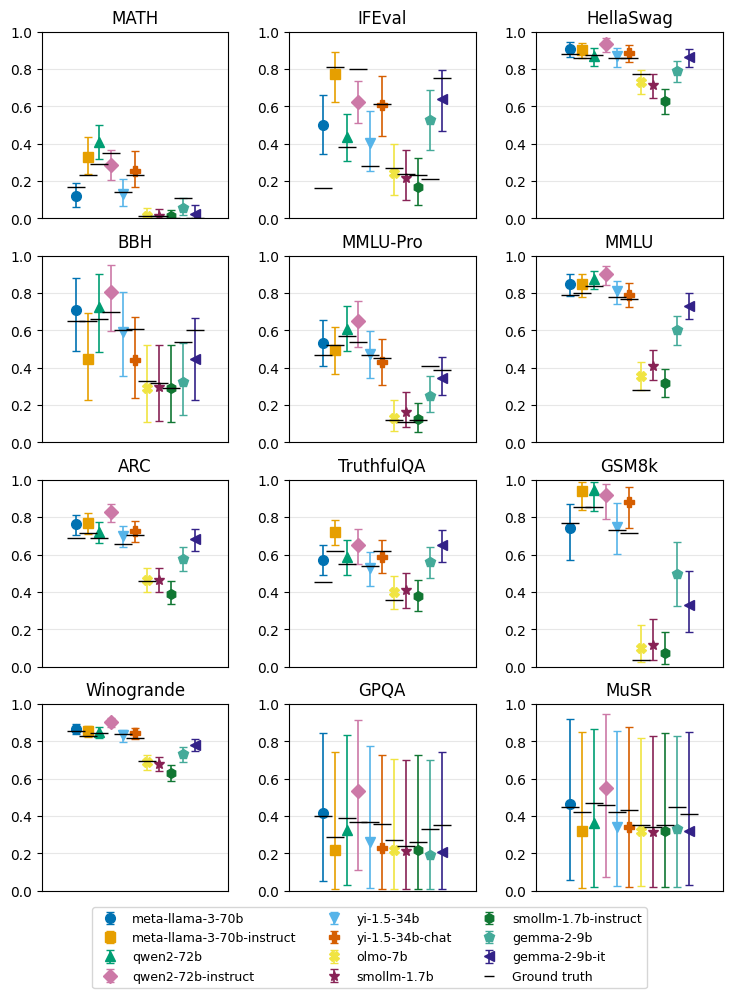

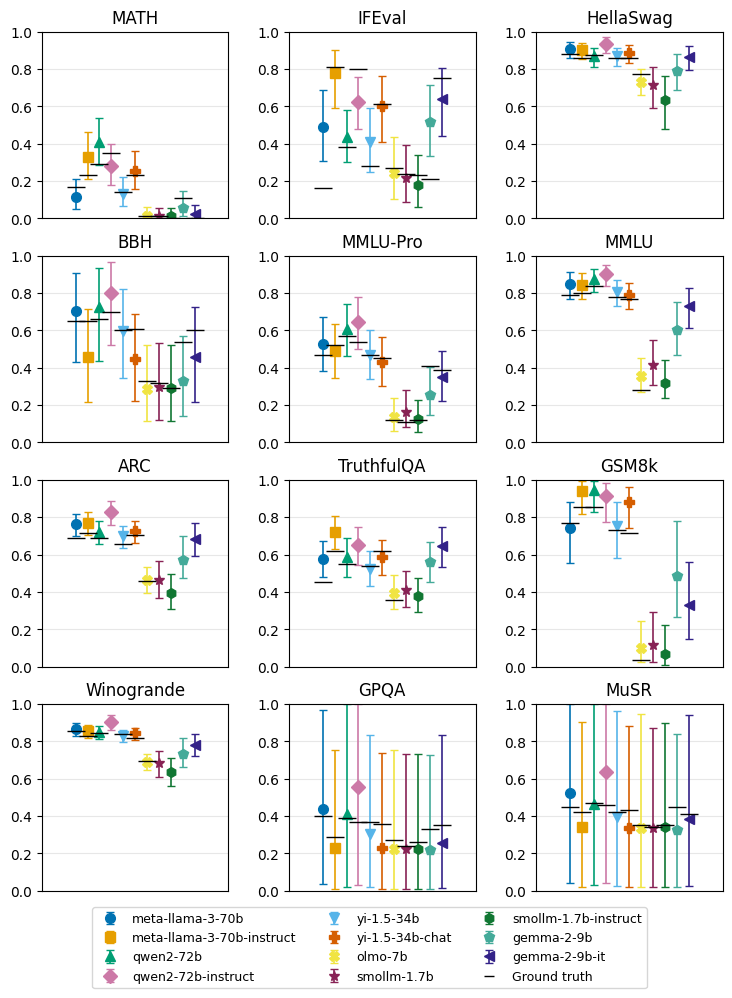

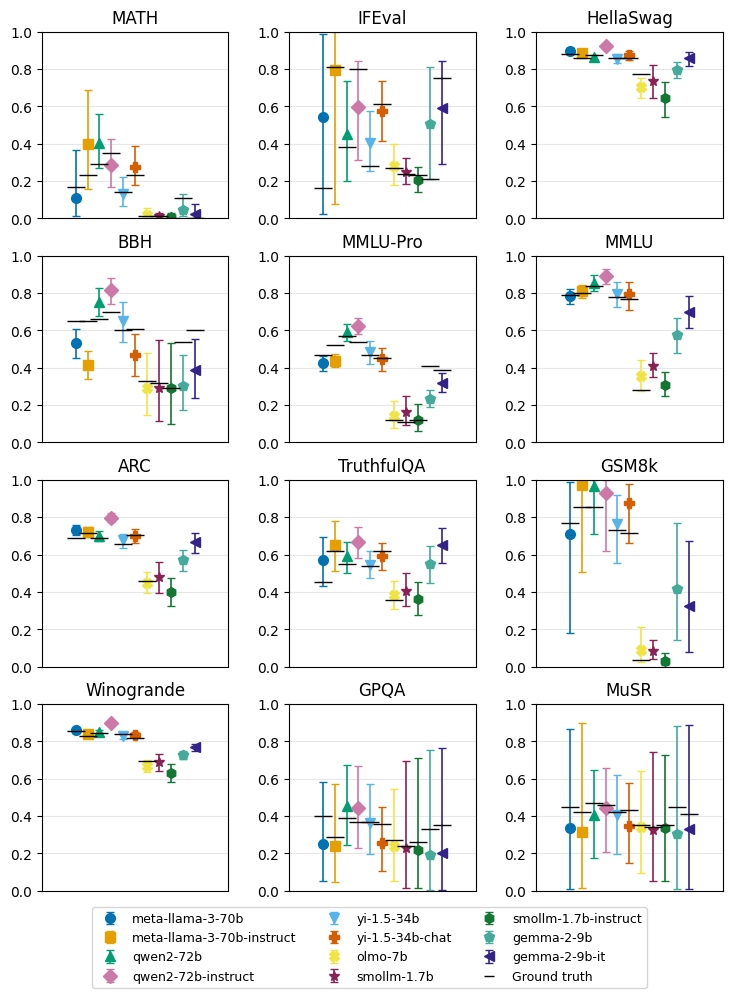

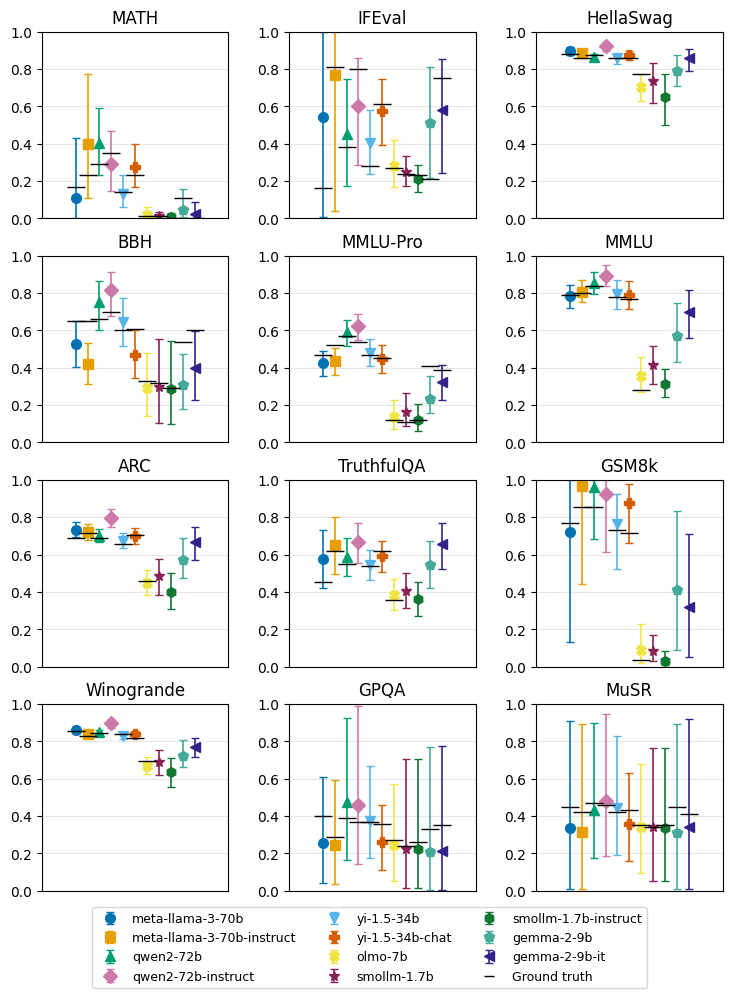

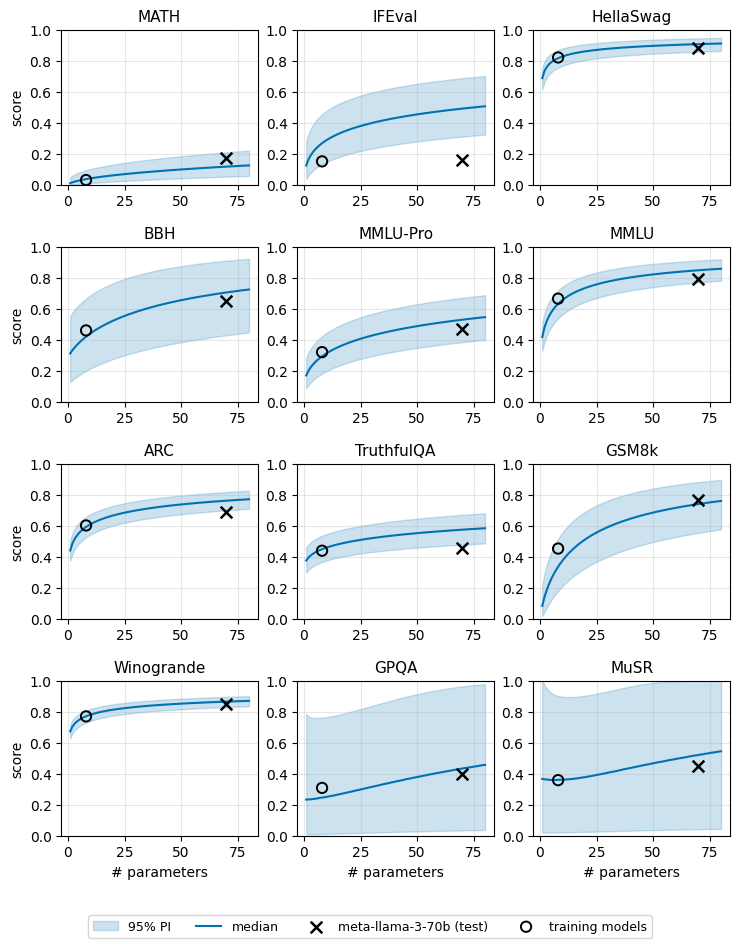

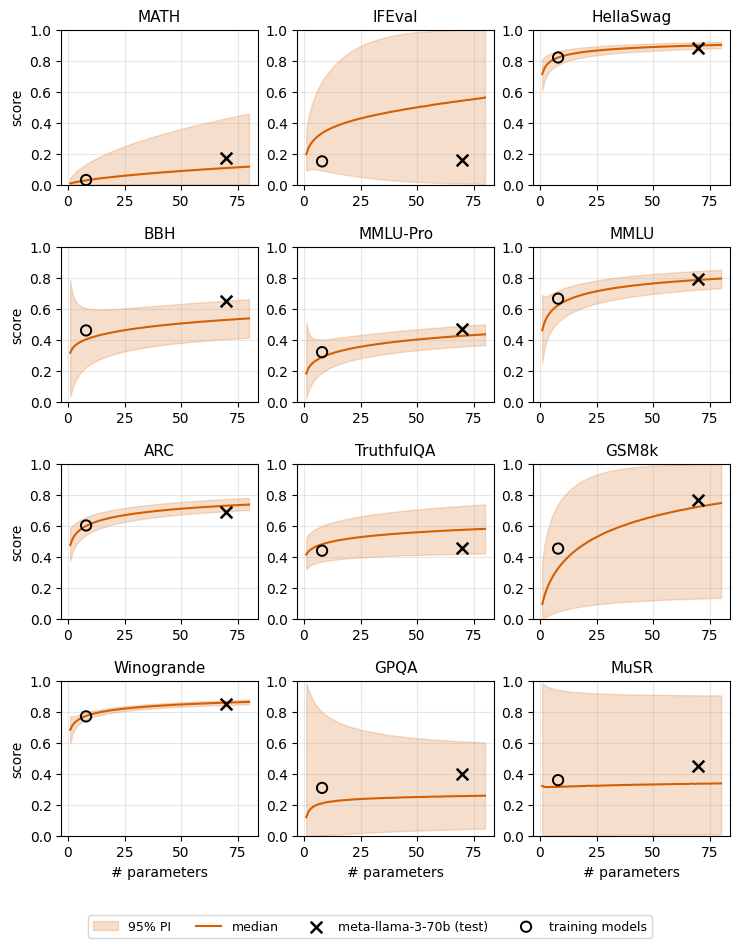

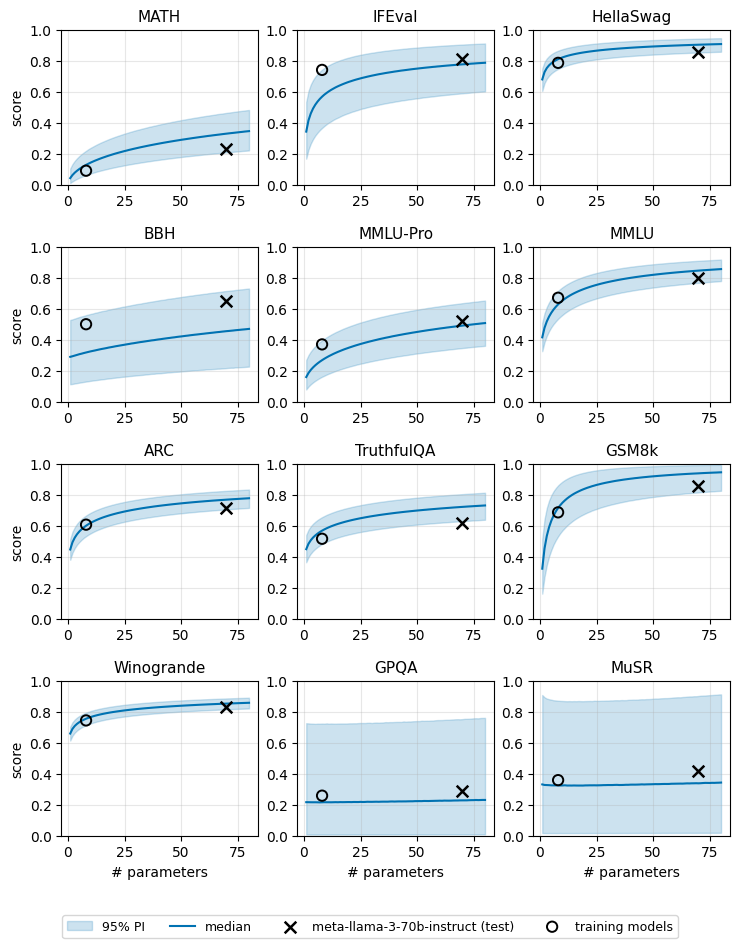

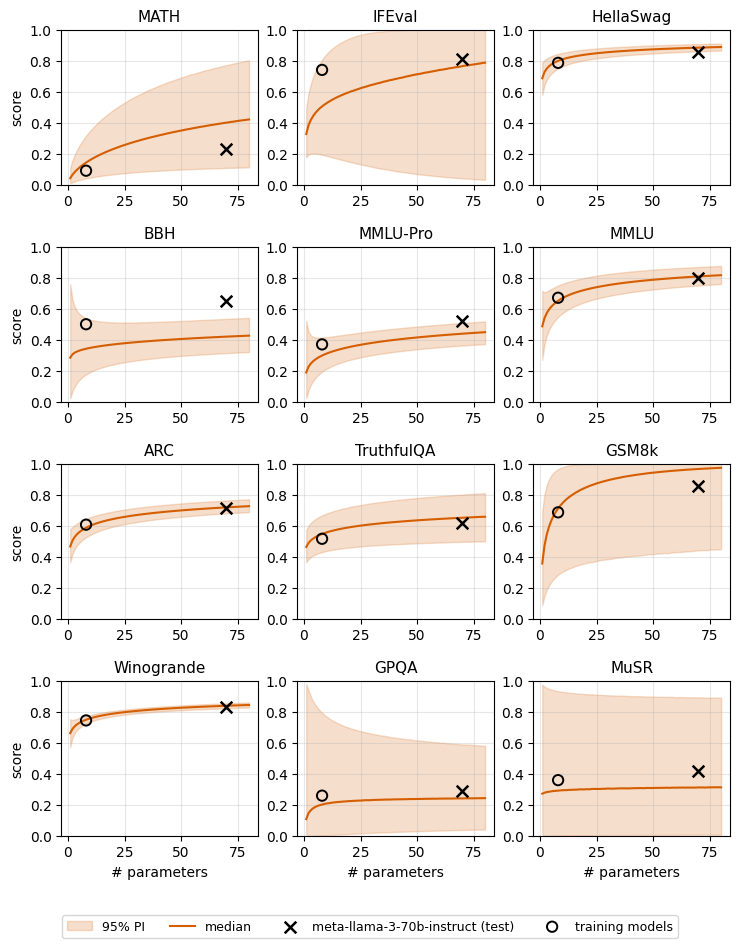

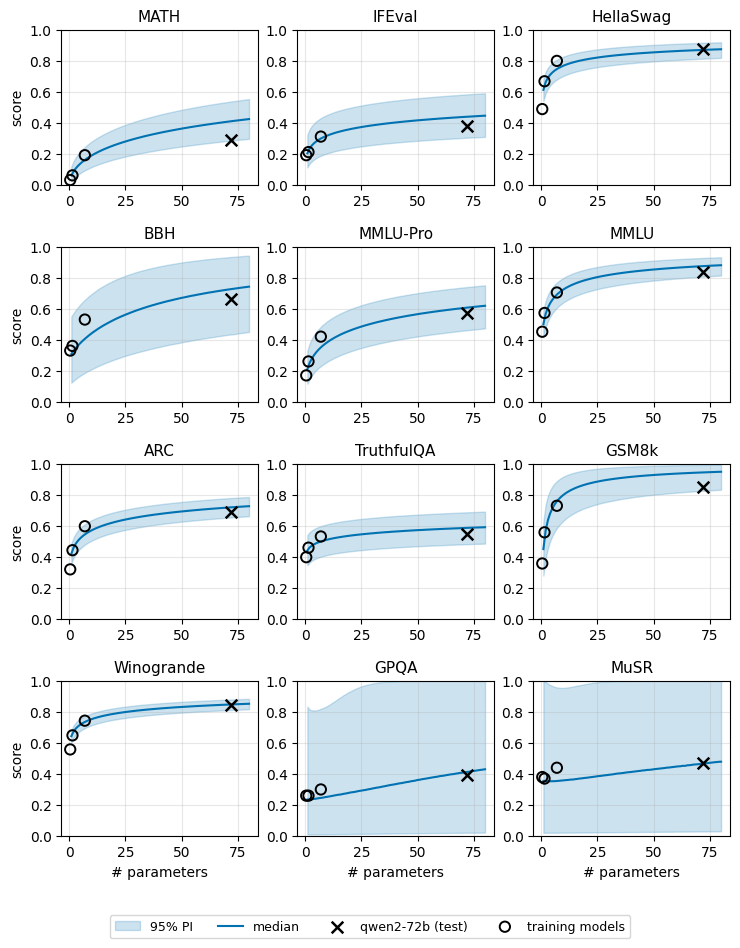

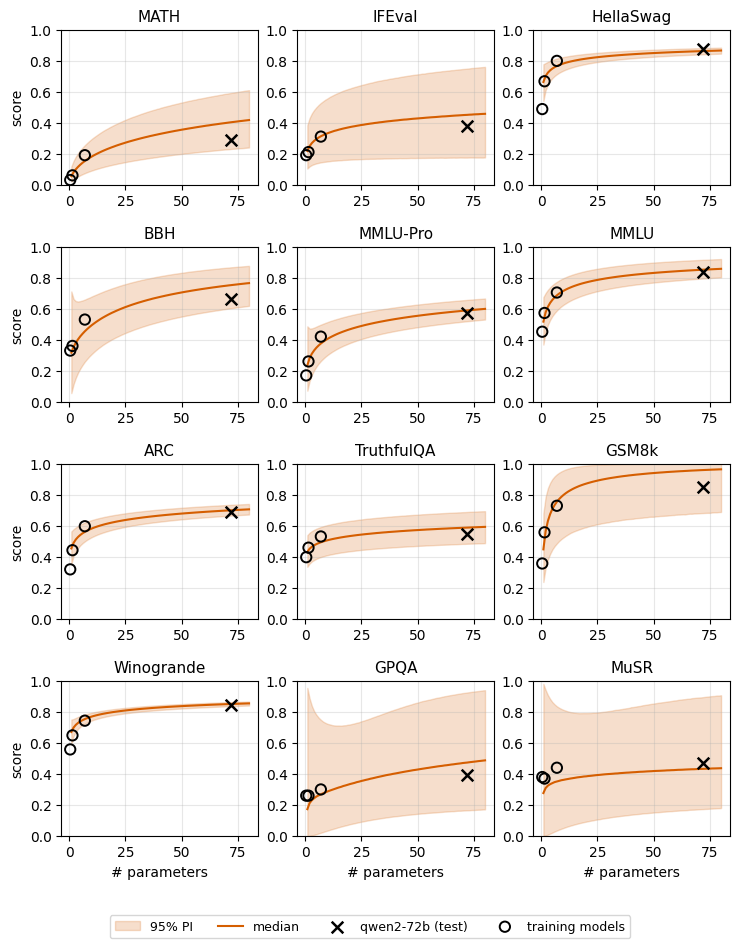

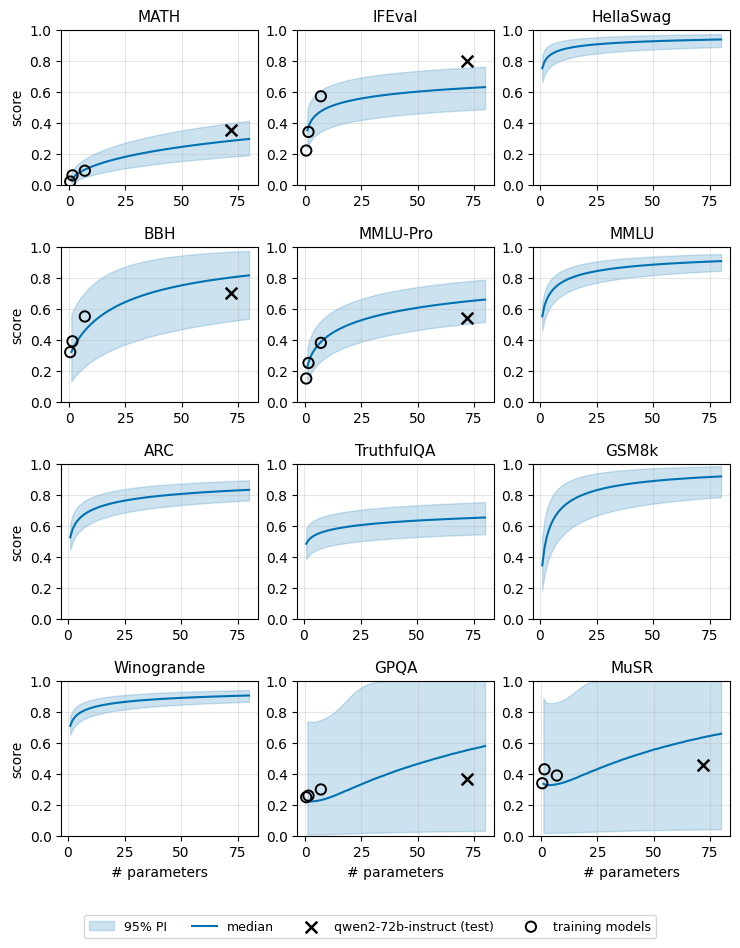

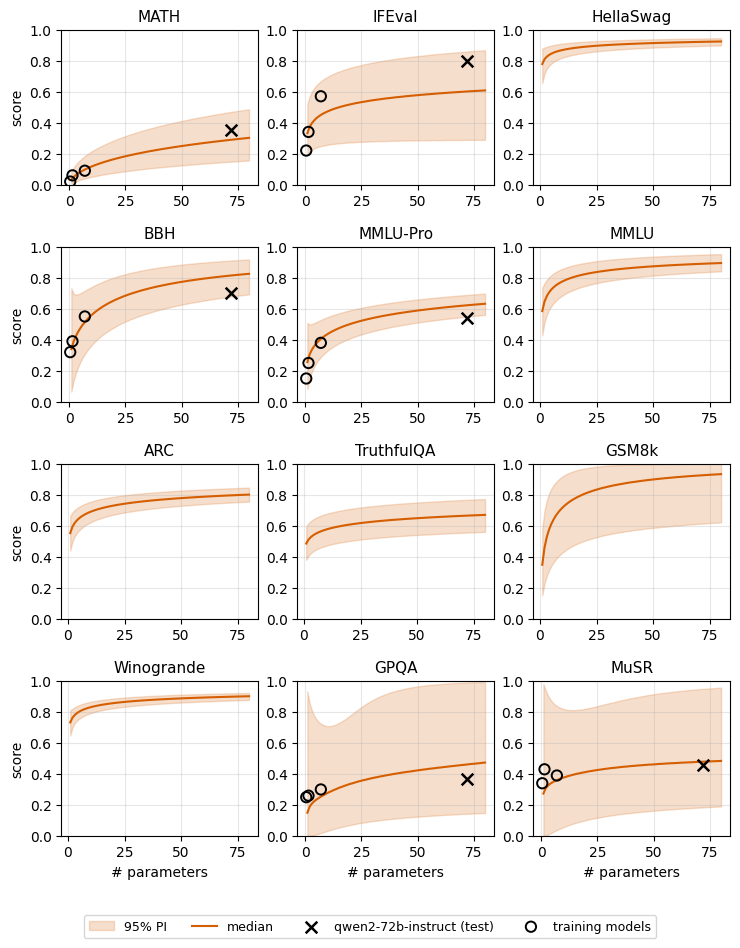

In [19]:
import os
os.makedirs('plots', exist_ok=True)

### Only on test
for m in ['model', 'model-general']:
    plot_benchmark_grid(predictions_avg, test_models, Y_names, model_key=m, ncols=3,
                        save_path=f'plots/benchmark_grid_avg_{m}.png')
    plot_benchmark_grid(predictions,     test_models, Y_names, model_key=m, ncols=3,
                        save_path=f'plots/benchmark_grid_full_{m}.png')

### Scaling
baby_models = {'meta-llama-3-70b':['meta-llama-3-8b'],
               'meta-llama-3-70b-instruct':['meta-llama-3-8b-instruct'],
               'qwen2-72b':['qwen2-0.5b', 'qwen2-1.5b', 'qwen2-7b'],
               'qwen2-72b-instruct':['qwen2-0.5b-instruct', 'qwen2-1.5b-instruct', 'qwen2-7b-instruct']}

for fam in ['meta-llama-3', 'qwen2']:
    for llm in test_models[fam]:
        grid_preds = compute_predictions_size_grid(
            samples=samples, pred_models=pred_models, test_models=test_models, C=C,
            fam=fam, llm=llm, n_grid=80, size_range=(1, 80), m=1000, use_average=False,
        )
        plot_size_grid(grid_preds, pred_models, test_models, df, Y_names, Y_names_tidy,
                       baby_models=baby_models, model_key='model',
                       band_color='#0072B2', median_color='#0072B2',
                       save_path=f'plots/scaling_{fam}_{llm}_model.png')
        plot_size_grid(grid_preds, pred_models, test_models, df, Y_names, Y_names_tidy,
                       baby_models=baby_models, model_key='model-general',
                       band_color='#D55E00', median_color='#D55E00',
                       save_path=f'plots/scaling_{fam}_{llm}_model-general.png')